# <span style="color:darkblue"> The Birthday Problem </span>

<font size="5">

Here is a question we can answer by simulation: if 50 people are in a room, how likely is it that *at least two* of them share a birthday?

Instead of working out the probability with a formula, we will *imagine many random rooms of 50 people*, check each room for a shared birthday, and see how often it happens. To keep the numbers simple, we will assume every month has 30 days (so there are 12 × 30 = 360 possible birthdays).

We will build up to the full simulation one piece at a time.

<font size = "5">

### Loop Warm-Up

Before getting started, let's review two ways to use `for` loops.

1. Use a `for` loop to print each day in the `days` list.
2. Use `range()` and `len()` to print each day by accessing it with its index.

In [3]:
days = [3, 8, 14, 21, 27]

# 1. Loop through the list
# YOUR CODE HERE

for day in range(len(days)):
    print(days[day])


# 2. Loop through the indices
# YOUR CODE HERE

3
8
14
21
27


In [4]:
import random
# The 50 people in our room (each entry is [name, month, day, year])
birthdays = [
    ["Abed", "March", 23, 2007],
    ["Britta", "July", 14, 1998],
    ["Jeff", "December", 8, 1990],
    ["Shirley", "January", 19, 1990],
    ["Annie", "September", 27, 2007],
    ["Troy", "June", 5, 2007],
    ["Pierce", "December", 30, 1962],
    ["Chang", "April", 17, 1987],
    ["Craig", "August", 11, 1985],
    ["Magnitude", "February", 22, 1983],
    ["Garrett", "October", 3, 2001],
    ["Vicki", "May", 29, 2003],
    ["Todd", "March", 16, 1997],
    ["Starburns", "July", 7, 1982],
    ["Neil", "January", 25, 1998],
    ["Leonard", "November", 13, 1993],
    ["Willy", "September", 4, 1981],
    ["Pavel", "June", 21, 1980],
    ["Quendra", "December", 9, 1982],
    ["Rich", "April", 28, 1986],
    ["Duncan", "August", 15, 1987],
    ["Hickey", "February", 6, 1996],
    ["Buzz", "October", 24, 1999],
    ["Rachel", "May", 18, 1980],
    ["Ian", "March", 12, 1997],
    ["Elroy", "July", 30, 1986],
    ["Frankie", "November", 2, 2002],
    ["Natalie", "September", 20, 2000],
    ["Owen", "June", 11, 2002],
    ["Paula", "December", 26, 1997],
    ["Quinn", "April", 1, 1993],
    ["Roger", "August", 17, 1987],
    ["Sara", "February", 8, 1994],
    ["Tim", "October", 22, 1998],
    ["Uma", "May", 14, 1988],
    ["Victor", "January", 29, 2005],
    ["Wendy", "July", 5, 2007],
    ["Xavier", "March", 19, 1980],
    ["Yolanda", "November", 10, 2004],
    ["Zara", "September", 3, 2005],
    ["Alex", "June", 27, 1985],
    ["Blake", "December", 16, 2002],
    ["Casey", "April", 7, 1993],
    ["Dana", "August", 23, 1990],
    ["Eli", "February", 18, 1988],
    ["Fiona", "October", 12, 1984],
    ["George", "May", 25, 1986],
    ["Hana", "January", 6, 2004],
    ["Ivan", "July", 21, 1990],
    ["Julia", "March", 15, 1983],
]

months = ["January", "February", "March", "April",
          "May", "June", "July", "August",
          "September", "October", "November", "December"]

print(len(birthdays), "people in the room")

50 people in the room


<font size = "5">

**1.** Take the first person out of `birthdays` and give them a brand-new random birthday, while keeping their name and year.

- Make a **copy** of the person first (remember from Lecture 6: without `.copy()`, you would change the original `birthdays` list!).
- Print the person before and after.

In [21]:
help(random.random)

Help on built-in function random:

random() method of random.Random instance
    random() -> x in the interval [0, 1).



In [25]:
# YOUR CODE HERE

print(birthdays[0])
copy_of_birthdays = birthdays.copy() 

print(copy_of_birthdays)
copy_of_birthdays[0] = [copy_of_birthdays[0][0],random.choice(months),random.randrange(1,30),copy_of_birthdays[0][3]]
print(copy_of_birthdays[0])


['Abed', 'March', 23, 2007]
[['Abed', 'March', 23, 2007], ['Britta', 'July', 14, 1998], ['Jeff', 'December', 8, 1990], ['Shirley', 'January', 19, 1990], ['Annie', 'September', 27, 2007], ['Troy', 'June', 5, 2007], ['Pierce', 'December', 30, 1962], ['Chang', 'April', 17, 1987], ['Craig', 'August', 11, 1985], ['Magnitude', 'February', 22, 1983], ['Garrett', 'October', 3, 2001], ['Vicki', 'May', 29, 2003], ['Todd', 'March', 16, 1997], ['Starburns', 'July', 7, 1982], ['Neil', 'January', 25, 1998], ['Leonard', 'November', 13, 1993], ['Willy', 'September', 4, 1981], ['Pavel', 'June', 21, 1980], ['Quendra', 'December', 9, 1982], ['Rich', 'April', 28, 1986], ['Duncan', 'August', 15, 1987], ['Hickey', 'February', 6, 1996], ['Buzz', 'October', 24, 1999], ['Rachel', 'May', 18, 1980], ['Ian', 'March', 12, 1997], ['Elroy', 'July', 30, 1986], ['Frankie', 'November', 2, 2002], ['Natalie', 'September', 20, 2000], ['Owen', 'June', 11, 2002], ['Paula', 'December', 26, 1997], ['Quinn', 'April', 1, 1993],

<font size = "5">

**2.** Now do that for every person in the room. Starting from an empty list, use a `for` loop to build a new list called `room`, where each entry is a copy of a real person but with a random month and day.

Print the first few entries and check that `len(room)` is 50.

*(We keep the `[name, month, day, year]` format so that later we can say exactly **who** shares a birthday.)*

In [27]:
# YOUR CODE HERE

room = birthdays.copy()
index = 0

for people in room:
    room[index] = [room[index][0],random.choice(months),random.randrange(1,30),room[index][3]]
    index = index + 1

print(room)


[['Abed', 'November', 8, 2007], ['Britta', 'September', 26, 1998], ['Jeff', 'May', 19, 1990], ['Shirley', 'March', 17, 1990], ['Annie', 'October', 19, 2007], ['Troy', 'June', 10, 2007], ['Pierce', 'May', 28, 1962], ['Chang', 'December', 7, 1987], ['Craig', 'January', 22, 1985], ['Magnitude', 'August', 28, 1983], ['Garrett', 'August', 27, 2001], ['Vicki', 'April', 11, 2003], ['Todd', 'June', 8, 1997], ['Starburns', 'January', 25, 1982], ['Neil', 'December', 27, 1998], ['Leonard', 'April', 26, 1993], ['Willy', 'February', 9, 1981], ['Pavel', 'May', 13, 1980], ['Quendra', 'August', 24, 1982], ['Rich', 'November', 21, 1986], ['Duncan', 'September', 22, 1987], ['Hickey', 'September', 12, 1996], ['Buzz', 'November', 4, 1999], ['Rachel', 'February', 29, 1980], ['Ian', 'November', 9, 1997], ['Elroy', 'November', 25, 1986], ['Frankie', 'December', 15, 2002], ['Natalie', 'January', 5, 2000], ['Owen', 'November', 17, 2002], ['Paula', 'May', 27, 1997], ['Quinn', 'March', 22, 1993], ['Roger', 'Febr

<font size = "5">

**3.** Using an `if` / `else` statement with `and`, check whether the first two people in `room` share a birthday, and print "match" if they do and "miss" if they don't.


In [28]:
# YOUR CODE HERE
# pull first value, 2 + 3

if room[0][2] and room[0][3] == room[1][2] and room[1][3]:
    print("match")
elif room[0][2] and room[0][3] != room[1][2] and room[1][3]:
    print("no match")
else:
    print("fuck")

no match


<font size = "5">

**4.** Now check the first person against *everyone else* in the room.

- Create `found = False` before the loop.
- Loop over positions 1, 2, 3, ... and compare person 0 to the person at each position (month and day).
- If you find a match, print who it is, set `found = True`, and `break`.
- Print `found` at the end.

In [ ]:
# YOUR CODE HERE

found = False
index = 1

for people in room:
    if room[0][2] and room [0][3] == room[index][2] and room [index][3]:
        found = True
        print("found")
        break

<font size = "5">

**5.** To answer the real question we must check *every pair* of people, using a loop inside a loop:

- The **outer** loop picks the first person of the pair, `room[i]`.
- The **inner** loop picks a *later* person, `room[j]`, so we never compare a person to themselves or check the same pair twice. We get "later" people with `range(i + 1, num_people)`, which produces i+1, i+2, ... , num_people - 1.

Use a `found = False` flag, and print the names whenever you find a matching pair.

In [62]:
# YOUR CODE HERE

person_1_counter = 0
person_2_counter = person_1_counter + 1
print(room)

for people in room:
    for i in range(person_1_counter + 1,len(room)):
        if room[person_1_counter][1] == room[person_2_counter][1] and room[person_1_counter][2] == room[person_2_counter][2]:
            found = True
            print(f"{room[person_1_counter][0]} and {room[person_2_counter][0]} have the same birthday")
        person_2_counter = person_2_counter + 1
    person_1_counter = person_1_counter + 1
    person_2_counter = person_1_counter + 1

print(found)



[['Abed', 'November', 8, 2007], ['Britta', 'September', 26, 1998], ['Jeff', 'May', 19, 1990], ['Shirley', 'March', 17, 1990], ['Annie', 'October', 19, 2007], ['Troy', 'June', 10, 2007], ['Pierce', 'May', 28, 1962], ['Chang', 'December', 7, 1987], ['Craig', 'January', 22, 1985], ['Magnitude', 'August', 28, 1983], ['Garrett', 'August', 27, 2001], ['Vicki', 'April', 11, 2003], ['Todd', 'June', 8, 1997], ['Starburns', 'January', 25, 1982], ['Neil', 'December', 27, 1998], ['Leonard', 'April', 26, 1993], ['Willy', 'February', 9, 1981], ['Pavel', 'May', 13, 1980], ['Quendra', 'August', 24, 1982], ['Rich', 'November', 21, 1986], ['Duncan', 'September', 22, 1987], ['Hickey', 'September', 12, 1996], ['Buzz', 'November', 4, 1999], ['Rachel', 'February', 29, 1980], ['Ian', 'November', 9, 1997], ['Elroy', 'November', 25, 1986], ['Frankie', 'December', 15, 2002], ['Natalie', 'January', 5, 2000], ['Owen', 'November', 17, 2002], ['Paula', 'May', 27, 1997], ['Quinn', 'March', 22, 1993], ['Roger', 'Febr

<font size = "5">

**6.** Putting Exercises 2 and 5 together, one **trial** is: *fill the room with random birthdays, then check whether any two match.* Combine them into a single cell that produces one `True`/`False` answer for one random room.


In [ ]:
# YOUR CODE HERE


RandomRoom = birthdays.copy()
index = 0

for people in RandomRoom:
    RandomRoom[index] = [RandomRoom[index][0],random.choice(months),random.randrange(1,30),RandomRoom[index][3]]
    index = index + 1



It is True that at least two people share a birthday in the room.


In [ ]:
#screw this, build iterable for n people in n rooms

SizeRoom = birthdays.copy()
RoomCap = 50
NRoom = range(0,49)
IndexPeople = 0 
person_1_counter = 0
person_2_counter = person_1_counter + 1
BirthdaysFound = 0

for i in NRoom:
    for people in SizeRoom:
        SizeRoom[IndexPeople] = [SizeRoom[IndexPeople][0],random.choice(months),random.randrange(1,31),SizeRoom[IndexPeople][3]]
        IndexPeople = IndexPeople + 1
        if RoomCap == IndexPeople:
            del SizeRoom[RoomCap:len(SizeRoom)]
        for people in SizeRoom:
            for p in range(person_1_counter + 1,len(SizeRoom)):
                if SizeRoom[person_1_counter][1] == SizeRoom[person_2_counter][1] and SizeRoom[person_1_counter][2] == SizeRoom[person_2_counter][2]:
                    found = True
                    print(f"{SizeRoom[person_1_counter][0]} and {SizeRoom[person_2_counter][0]} in room {i + 1} have the same birthday")
                    print(f"{SizeRoom[person_1_counter][1]} and {SizeRoom[person_2_counter][1]}")
                    print(f"{SizeRoom[person_1_counter][2]} and {SizeRoom[person_2_counter][2]}")
                person_2_counter = person_2_counter + 1
                if found == True:
                    BirthdaysFound = BirthdaysFound + 1
                    found = False
            person_1_counter = person_1_counter + 1
            person_2_counter = person_1_counter + 1
    IndexPeople = 0
    person_1_counter = 0
    person_2_counter = person_1_counter + 1

            
        


print(SizeRoom)
print(BirthdaysFound)

#just need to fix levels of loop


Britta and Dana in room 2 have the same birthday
March and March
15 and 15
Troy and Neil in room 2 have the same birthday
November and November
19 and 19
Leonard and Rich in room 2 have the same birthday
February and February
29 and 29
Duncan and Natalie in room 2 have the same birthday
September and September
16 and 16
Duncan and Ivan in room 2 have the same birthday
September and September
16 and 16
Natalie and Ivan in room 2 have the same birthday
September and September
16 and 16
Quinn and Wendy in room 2 have the same birthday
June and June
3 and 3
Magnitude and Blake in room 3 have the same birthday
February and February
18 and 18
Pavel and Yolanda in room 3 have the same birthday
November and November
8 and 8
Buzz and Alex in room 3 have the same birthday
February and February
23 and 23
Starburns and Zara in room 4 have the same birthday
November and November
14 and 14
Hickey and Roger in room 4 have the same birthday
July and July
15 and 15
Quinn and Uma in room 4 have the same

<font size = "5">

**7.** A single trial only says `True` or `False`. To *estimate* a probability, repeat the trial many times and count how often a shared birthday happens.

Wrap the whole trial from Exercise 6 inside an **outer loop** that runs 100 times. Keep a counter `num_found` that goes up by 1 whenever a trial has a shared birthday, then divide by the number of trials.

Out of 100 random rooms of 50 people, how many had at least two people sharing a birthday? Are you surprised?

In [ ]:
# YOUR CODE HERE

In 96 out of 100 rooms, at least two people shared a birthday.
Estimated probability: 0.96


<font size = "5">

**8.** The surprising part of the birthday problem is how *few* people you need. Estimate the probability for several room sizes and draw a bar plot.

- For each room size in `size = [5, 10, 25, 50]`, run 100 trials. 
  - append the estimated probability of a match for that room size to a list called `estimates`.
- Collect the estimates into a list and plot them with `plt.bar`.

Watch what happens around 25 people.

Room sizes: [5, 10, 25, 50]
Estimates: [0.02, 0.19, 0.67, 0.96]


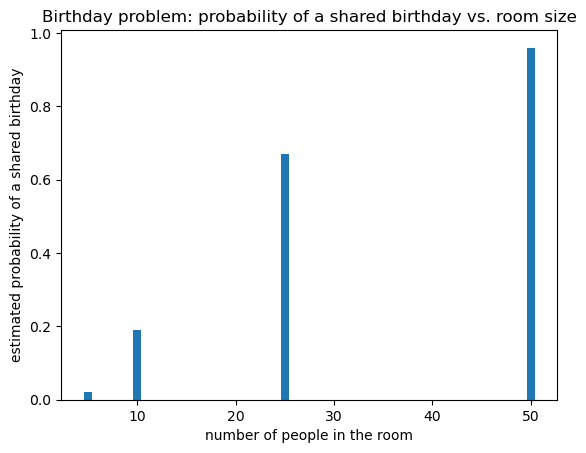

In [ ]:
# YOUR CODE HERE